# **Optimalisasi Strategi Bisnis Melalui Analisis Clustering Pola Pembelian Pelanggan**

**Cluster 0: Transaksi dengan Nilai Tinggi**

Unit price: Rp78,046 (rata-rata harga per unit tertinggi).
Quantity: 7.83 (rata-rata kuantitas tertinggi).
Tax 5%: Rp102.32 (pajak tertinggi).
Total: Rp2,012,188 (total nilai transaksi tertinggi).
cogs: Rp608.04 (biaya produksi tinggi).
gross income: Rp102.32 (pendapatan kotor tertinggi).
Rating: 6.75 (rating sedikit lebih rendah dibanding cluster lain).
Insight:
Cluster ini mencerminkan pelanggan yang melakukan pembelian dalam jumlah besar dengan produk mahal.
Fokus strategi: program loyalitas, insentif khusus, atau personalisasi layanan.

**Cluster 1: Transaksi dengan Nilai Menengah**

Unit price: Rp31,189 (harga per unit lebih rendah dari Cluster 0).
Quantity: 7.15 (masih cukup tinggi, tapi di bawah Cluster 0).
Tax 5%: Rp25.78 (pajak menengah).
Total: Rp503,755 (total nilai transaksi menengah).
cogs: Rp224.87 (biaya produksi menengah).
gross income: Rp25.78 (pendapatan kotor menengah).
Rating: 7.13 (rating tertinggi di antara cluster lain).
Insight:
Cluster ini adalah pelanggan yang sering membeli barang dengan harga lebih terjangkau tetapi dalam jumlah besar.
Fokus strategi: tawarkan promosi untuk meningkatkan kuantitas pembelian.

**Cluster 2: Transaksi dengan Nilai Rendah**

Unit price: Rp58,394 (harga per unit cukup tinggi, tetapi lebih rendah dari Cluster 0).
Quantity: 2.52 (kuantitas terendah di antara cluster).
Tax 5%: Rp16.97 (pajak terendah).
Total: Rp334,607 (total nilai transaksi terendah).
cogs: Rp151.40 (biaya produksi rendah).
gross income: Rp16.97 (pendapatan kotor terendah).
Rating: 7.02 (rating lebih tinggi dari Cluster 0, tetapi di bawah Cluster 1).
Insight:
Cluster ini menunjukkan pelanggan yang membeli dalam jumlah kecil tetapi mungkin dengan produk bernilai lebih tinggi.
Fokus strategi: promosikan paket bundling atau diskon untuk meningkatkan pembelian.


Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
from google.colab import files

Data Selection

In [ ]:
df = pd.read_csv('supermarket_sales.csv', delimiter=';')

In [ ]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750678428,A,Yangon,Member,Female,Health and beauty,74.69,7,261.415,5.489.715,01/05/2019,13:08,Ewallet,522.83,4.761.904.762,261.415,9.1
1,226313081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.820,80.22,03/08/2019,10:29,Cash,76.40,4.761.904.762,3.820,9.6
2,631413108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,162.155,3.405.255,03/03/2019,13:23,Credit card,324.31,4.761.904.762,162.155,7.4
3,123191176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.288,489.048,1/27/2019,20:33,Ewallet,465.76,4.761.904.762,23.288,8.4
4,373737910,A,Yangon,Normal,Male,Sports and travel,86.31,7,302.085,6.343.785,02/08/2019,10:37,Ewallet,604.17,4.761.904.762,302.085,5.3


In [ ]:
# Memeriksa missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [ ]:
# Melihat tipe data setiap kolom
print(df.dtypes)

Invoice ID                   int64
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                       object
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage     object
gross income               float64
Rating                     float64
dtype: object


In [ ]:
df['Total'] = df['Total'].str.replace('.', '').astype(float)

In [ ]:
df['gross margin percentage'] = df['gross margin percentage'].str.rstrip('%').str.replace('.', '', regex=False).astype('float') / 100.0

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')
print(df.dtypes)

Invoice ID                          int64
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object


In [ ]:
# Pengecekan Duplicate Data
duplicate_rows = df.duplicated().sum()
print("\nJumlah duplicate data:", duplicate_rows)


Jumlah duplicate data: 0


Data Mining

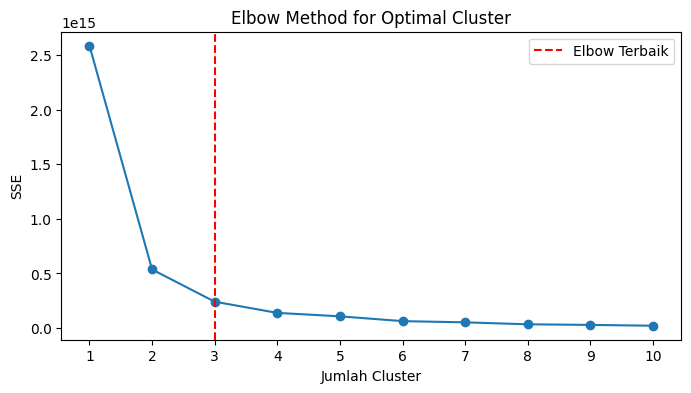

Elbow terbaik ada pada jumlah cluster: 3


In [ ]:
# Mengambil kolom numerik yang diperlukan
df_clustering = df[['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs','gross income', 'Rating']]
sse = []

# Inisialisasi model K-Means
for i in range (1,11):
  kmeans = KMeans(n_clusters=i, init = 'k-means++', random_state=42)
  kmeans.fit(df_clustering)
  sse.append(kmeans.inertia_)

# Plot Elbow Method (SSE)
plt.figure(figsize=(8, 4))
plt.plot(range(1,11), sse, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal Cluster')

# Menemukan indeks elbow terbaik
elbow_index = 0
for i in range(1, len(sse) - 1):
    elbow_diff = sse[i] - sse[i + 1]
    if elbow_diff < 0.1 * sse[0]:
        elbow_index = i
        break

plt.axvline(x=elbow_index + 1, color='r', linestyle='--', label='Elbow Terbaik')
plt.xticks(range(1, 11))
plt.legend()
plt.show()
print(f"Elbow terbaik ada pada jumlah cluster: {elbow_index + 1}")

In [ ]:
# Proses Clustering K-Means dengan jumlah cluster = 3

kmeans = KMeans(n_clusters=3, random_state= 42)

# Normalisasi data menggunakan MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(df_clustering)
kmeans.fit(data)

# Mendapatkan centroid dan label
centroid = kmeans.cluster_centers_
print(centroid)
kmeans.labels_

# Dapatkan label klaster
labels = kmeans.labels_

# Isi indeks yang hilang dengan indeks sebenarnya
all_clusters = df.copy()
all_clusters["Cluster"] = labels

[[0.75619166 0.7587519  0.22712406 0.21345564 0.60831508 0.22712406
  0.45787671]
 [0.23486478 0.68345838 0.05638334 0.05339064 0.21845024 0.05638334
  0.5210075 ]
 [0.5375432  0.16876574 0.03671664 0.03544176 0.14369577 0.03671664
  0.50306465]]


In [ ]:
# Simpan hasil clustering ke file CSV
all_clusters.to_csv('hasil_clustering.csv')

In [ ]:
# Jalankan clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_clustering)

# Dapatkan label cluster untuk setiap data
labels = kmeans.labels_

# Periksa apakah ada data yang tidak masuk ke dalam cluster
print("Jumlah data yang tidak masuk ke dalam cluster:", (labels == -1).sum())

Jumlah data yang tidak masuk ke dalam cluster: 0


In [ ]:
# Mendeskripsikan Total Isi Tiap Cluster
df["Cluster"] = kmeans.labels_
n_cs = 3 # Jumlah cluster

# Tampilkan isi hasil dengan tabel
for i in range(n_cs):
    cluster_df = df[df['Cluster'] == i]
    cluster_df.insert(0, 'No', range(1, len(cluster_df) + 1))
    display(cluster_df)

,No,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Cluster
2,1,631413108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,162.155,3405255.0,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,47619047.62,162.155,7.4,0
12,2,365640515,A,Yangon,Normal,Female,Electronic accessories,46.95,5,117.375,2464875.0,2019-02-12,1900-01-01 10:25:00,Ewallet,234.75,47619047.62,117.375,7.1,0
16,3,656959349,A,Yangon,Member,Female,Health and beauty,68.93,7,241.255,5066355.0,2019-03-11,1900-01-01 11:03:00,Credit card,482.51,47619047.62,241.255,4.6,0
24,4,549591358,A,Yangon,Member,Male,Sports and travel,88.63,3,132.945,2791845.0,2019-03-02,1900-01-01 17:36:00,Ewallet,265.89,47619047.62,132.945,6.0,0
29,5,848627243,A,Yangon,Normal,Male,Health and beauty,24.89,9,112.005,2352105.0,2019-03-15,1900-01-01 15:36:00,Cash,224.01,47619047.62,112.005,7.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,93,846100341,A,Yangon,Normal,Female,Fashion accessories,42.57,7,148.995,3128895.0,2019-01-06,1900-01-01 11:51:00,Cash,297.99,47619047.62,148.995,6.8,0
956,94,577347579,C,Naypyitaw,Member,Male,Food and beverages,50.49,9,227.205,4771305.0,2019-01-10,1900-01-01 17:16:00,Cash,454.41,47619047.62,227.205,5.4,0
967,95,195060432,A,Yangon,Member,Male,Home and lifestyle,81.01,3,121.515,2551815.0,2019-01-13,1900-01-01 12:55:00,Credit card,243.03,47619047.62,121.515,9.3,0
971,96,448348700,B,Mandalay,Member,Male,Home and lifestyle,36.91,7,129.185,2712885.0,2019-02-10,1900-01-01 13:51:00,Ewallet,258.37,47619047.62,129.185,6.7,0


,No,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Cluster
1,1,226313081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.820,8022.0,2019-03-08,1900-01-01 10:29:00,Cash,76.40,47619047.62,3.820,9.6,1
3,2,123191176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.288,489048.0,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,47619047.62,23.288,8.4,1
6,3,355535943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.652,433692.0,2019-02-25,1900-01-01 14:36:00,Ewallet,413.04,47619047.62,20.652,5.8,1
7,4,315225665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.780,77238.0,2019-02-24,1900-01-01 11:38:00,Ewallet,735.60,47619047.62,36.780,8.0,1
8,5,665329167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.626,76146.0,2019-01-10,1900-01-01 17:15:00,Credit card,72.52,47619047.62,3.626,7.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,861,233675758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,20.175,423675.0,2019-01-29,1900-01-01 13:46:00,Ewallet,40.35,47619047.62,20.175,6.2,1
996,862,303962227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.690,102249.0,2019-03-02,1900-01-01 17:16:00,Ewallet,973.80,47619047.62,48.690,4.4,1
997,863,727021313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.592,33432.0,2019-02-09,1900-01-01 13:22:00,Cash,31.84,47619047.62,1.592,7.7,1
998,864,347562442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.291,69111.0,2019-02-22,1900-01-01 15:33:00,Cash,65.82,47619047.62,3.291,4.1,1


,No,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Cluster
0,1,750678428,A,Yangon,Member,Female,Health and beauty,74.69,7,261.415,5489715.0,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,47619047.62,261.415,9.1,2
4,2,373737910,A,Yangon,Normal,Male,Sports and travel,86.31,7,302.085,6343785.0,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,47619047.62,302.085,5.3,2
5,3,699143026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,298.865,6276165.0,2019-03-25,1900-01-01 18:30:00,Ewallet,597.73,47619047.62,298.865,4.1,2
31,4,149716266,B,Mandalay,Member,Male,Sports and travel,78.07,9,351.315,7377615.0,2019-01-28,1900-01-01 12:43:00,Cash,702.63,47619047.62,351.315,4.5,2
46,5,370417321,B,Mandalay,Member,Male,Health and beauty,56.69,9,255.105,5357205.0,2019-02-27,1900-01-01 17:24:00,Credit card,510.21,47619047.62,255.105,8.4,2
74,6,287219091,A,Yangon,Normal,Male,Home and lifestyle,74.67,9,336.015,7056315.0,2019-01-22,1900-01-01 10:55:00,Ewallet,672.03,47619047.62,336.015,9.4,2
101,7,189982939,C,Naypyitaw,Normal,Male,Fashion accessories,78.55,9,353.475,7422975.0,2019-03-01,1900-01-01 13:22:00,Cash,706.95,47619047.62,353.475,7.2,2
113,8,645441170,A,Yangon,Member,Male,Home and lifestyle,58.07,9,261.315,5487615.0,2019-01-19,1900-01-01 20:07:00,Ewallet,522.63,47619047.62,261.315,4.3,2
114,9,237016122,C,Naypyitaw,Member,Female,Home and lifestyle,80.79,9,363.555,7634655.0,2019-02-01,1900-01-01 20:31:00,Credit card,727.11,47619047.62,363.555,9.5,2
125,10,668908900,A,Yangon,Normal,Female,Home and lifestyle,93.69,7,327.915,6886215.0,2019-03-10,1900-01-01 18:44:00,Credit card,655.83,47619047.62,327.915,4.5,2


from matplotlib import pyplot as plt
cluster_df['No'].plot(kind='hist', bins=20, title='No')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
cluster_df['Invoice ID'].plot(kind='hist', bins=20, title='Invoice ID')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(cluster_df['City'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(cluster_df, x='No', y='City', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(cluster_df['Customer type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(cluster_df, x='No', y='Customer type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(cluster_df['Gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(cluster_df, x='No', y='Gender', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# Print jumlah isi untuk setiap cluster
for i in range(n_cs):
    cnt = df[df['Cluster'] == i]['Cluster'].count()
    print(f'Cluster {i}: {cnt} entri')

Cluster 0: 97 entri
Cluster 1: 865 entri
Cluster 2: 38 entri


In [ ]:
# Inisialisasi list untuk menyimpan nilai SSE
sse = []
for i in range (1,11):
  kmeans = KMeans(n_clusters=i, init = 'k-means++', random_state=42)
  kmeans.fit(df_clustering)
  sse.append(kmeans.inertia_)

for index, ssei in enumerate(sse):
  print(f'Nilai SSE untuk k(Cluster) = {index+1} is {ssei}')

Nilai SSE untuk k(Cluster) = 1 is 2584658119425395.0
Nilai SSE untuk k(Cluster) = 2 is 536265535707769.1
Nilai SSE untuk k(Cluster) = 3 is 241427735465301.44
Nilai SSE untuk k(Cluster) = 4 is 138969821682576.27
Nilai SSE untuk k(Cluster) = 5 is 107522393648609.02
Nilai SSE untuk k(Cluster) = 6 is 63549171450064.055
Nilai SSE untuk k(Cluster) = 7 is 52476502535610.625
Nilai SSE untuk k(Cluster) = 8 is 34468126720216.074
Nilai SSE untuk k(Cluster) = 9 is 29039680918048.09
Nilai SSE untuk k(Cluster) = 10 is 21550823237663.36


Davies-Bouldin Index untuk 2 cluster: 0.37505548170841146
Davies-Bouldin Index untuk 3 cluster: 0.4364800943566635
Davies-Bouldin Index untuk 4 cluster: 0.45648539922638465
Davies-Bouldin Index untuk 5 cluster: 0.45705190269486967
Davies-Bouldin Index untuk 6 cluster: 0.47415002612102936
Davies-Bouldin Index untuk 7 cluster: 0.4831216729452218
Davies-Bouldin Index untuk 8 cluster: 0.4907419017413702
Davies-Bouldin Index untuk 9 cluster: 0.4922033184336105
Davies-Bouldin Index untuk 10 cluster: 0.486348621602019


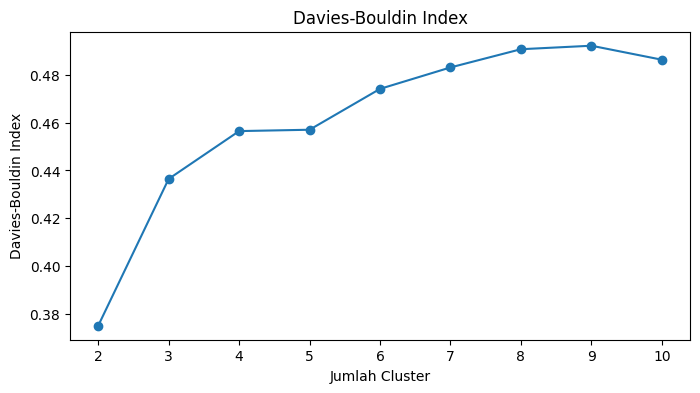

Jumlah cluster terbaik berdasarkan Davies-Bouldin Index: 2


In [ ]:
# Inisialisasi list untuk menyimpan nilai Davies-Bouldin Index
davies_bouldin_scores = []

# Melakukan clustering dengan jumlah cluster yang berbeda
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_clustering)

    # Menghitung Davies-Bouldin Index untuk jumlah cluster saat ini
    davies_bouldin_score_current = davies_bouldin_score(df_clustering, kmeans.labels_)
    davies_bouldin_scores.append(davies_bouldin_score_current)

    # Cetak angka Davies-Bouldin Index untuk setiap jumlah cluster
    print(f"Davies-Bouldin Index untuk {i} cluster: {davies_bouldin_score_current}")

# Jumlah cluster dengan Davies-Bouldin Index terendah
best_cluster_davies_bouldin = range(2, 11)[davies_bouldin_scores.index(min(davies_bouldin_scores))]

# Plot Davies-Bouldin Index
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), davies_bouldin_scores, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index')
plt.show()

print(f"Jumlah cluster terbaik berdasarkan Davies-Bouldin Index: {best_cluster_davies_bouldin}")